In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
df =  pd.read_csv('https://raw.githubusercontent.com/FauzanTrisuladana/content/refs/heads/master/kc_house_data.csv')

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530.0,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310.0,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020.0,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600.0,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020.0,0,2008,0,98144,47.5941,-122.299,1020,1357


In [5]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21611.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.396095,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.128162,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


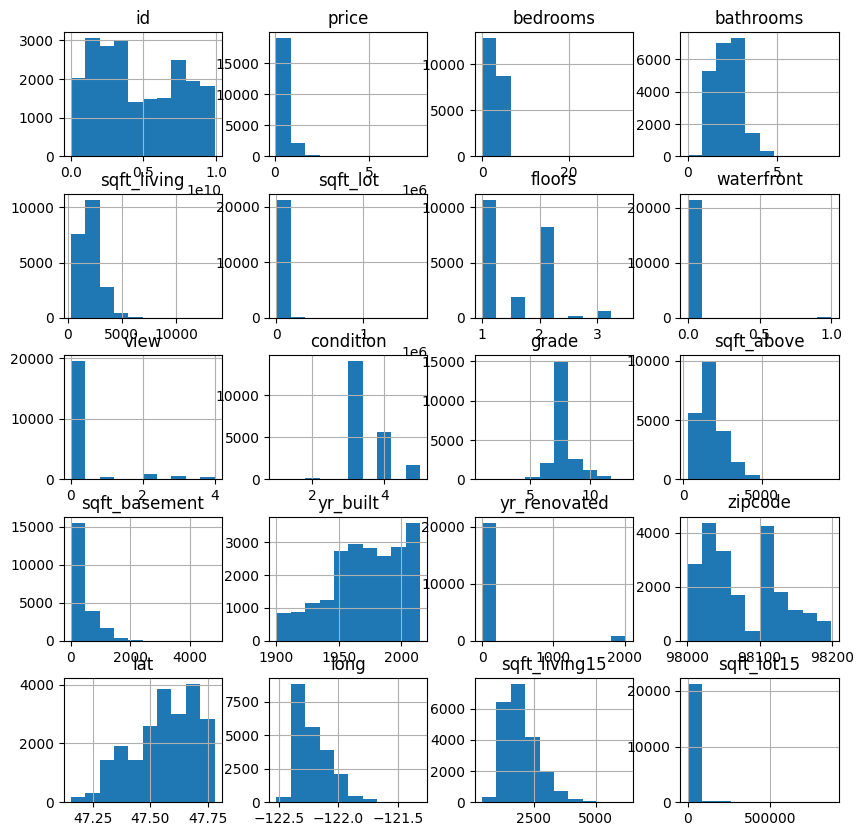

In [6]:
df.hist(figsize=(10,10))
plt.show()

In [7]:
df.corr(numeric_only=True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010830,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477616,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685363,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876644,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183511,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523899,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072074,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167648,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158206,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


In [8]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [9]:
df_X = df.drop(['id', 'date','price'], axis=1)
df_y = df['price']
cats = df_X.select_dtypes(include=['object', 'bool']).columns
print(cats)

df_X = df.drop(['id', 'date', 'price'], axis=1)
df_y = df['price']

# Ntah kenapa ada yang null
df_X['sqft_above'] = df_X['sqft_above'].fillna(df_X['sqft_above'].mean())

X = df_X.astype(float).values
y = df_y.astype(float).values

Index([], dtype='object')


Linear Regression

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
reg = LinearRegression()
reg.fit(X_train, y_train)

print('coef of determination training ', reg.score(X_train, y_train))
print('coef of determination testing ', reg.score(X_test, y_test))

print('coefficient')
print(reg.coef_)
print('intercept')
print(reg.intercept_)

print('prediction')
y_pred = reg.predict(X_test)
print(y_pred[:10])
print('real value')
print(y_test[0:10])

coef of determination training  0.6995366840765294
coef of determination testing  0.6990916626806885
coefficient
[-3.43457659e+04  4.02986571e+04 -2.66998150e+03  9.90453754e-02
  5.27465702e+03  5.43879867e+05  5.50631785e+04  2.31133953e+04
  9.48989792e+04  2.85426357e+03  2.82193796e+03 -2.59485979e+03
  2.18992681e+01 -5.56876667e+02  5.95234401e+05 -1.96868938e+05
  1.61752728e+01 -3.30598643e-01]
intercept
6697083.212488894
prediction
[ 458529.94223329  748988.15166255 1243285.18210807 1665136.33624995
  737329.74387254  283236.23732869  831720.86985719  495302.83791252
  385795.83621725  474162.01185866]
real value
[ 365000.  865000. 1038000. 1490000.  711000.  211000.  790000.  680000.
  384500.  605000.]


In [11]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('rmse', rmse)
print('r2', r2)

rmse 208425.26955033094
r2 0.6990916626806885


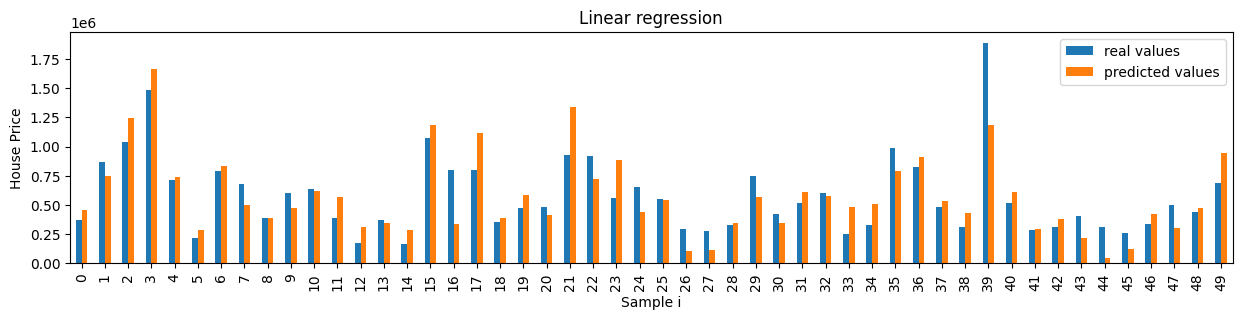

In [12]:
data1 = pd.Series(y_test[:50].ravel())
data2 = pd.Series(y_pred[:50].ravel())

df_new = pd.concat([data1, data2],keys=['real values','predicted values'], axis=1)
#df_new.plot.bar() #bisa pakai cara 1
df_new.plot(kind='bar', figsize=(15,3)) # bisa pakai cara 2

plt.title("Linear regression")
plt.xlabel('Sample i')
plt.ylabel('House Price')
plt.show()

Decision Tree Regression

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rf = DecisionTreeRegressor()
rf.fit(X_train, y_train)

print('coef of determination training ', rf.score(X_train, y_train))
print('coef of determination testing ', rf.score(X_test, y_test))

print('prediction')
y_pred = rf.predict(X_test)
print(y_pred[:10])
print('real value')
print(y_test[0:10])

coef of determination training  0.9993609592350591
coef of determination testing  0.7316679102834533
prediction
[ 397500.  810000.  962800. 2250000.  662000.  215000.  898000.  655000.
  375000.  595000.]
real value
[ 365000.  865000. 1038000. 1490000.  711000.  211000.  790000.  680000.
  384500.  605000.]


In [14]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('rmse', rmse)
print('r2', r2)

rmse 196820.1542228394
r2 0.7316679102834533


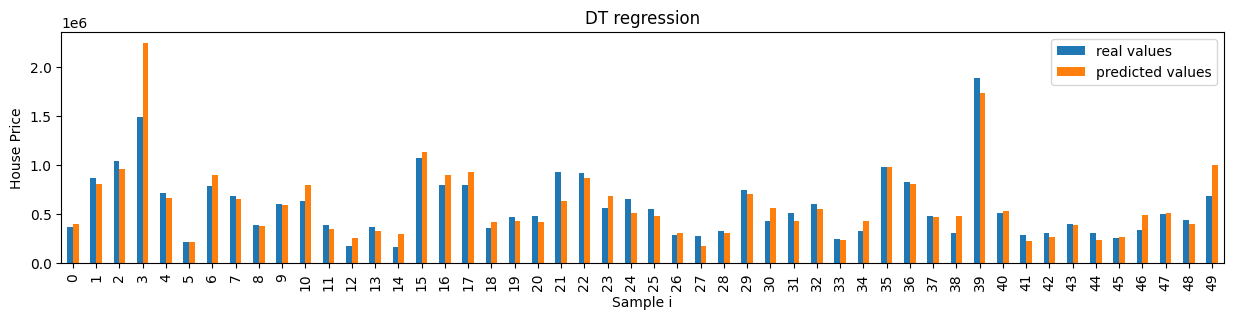

In [15]:
data1 = pd.Series(y_test[:50].ravel())
data2 = pd.Series(y_pred[:50].ravel())

df_new = pd.concat([data1, data2],keys=['real values','predicted values'], axis=1)
#df_new.plot.bar() #bisa pakai cara 1
df_new.plot(kind='bar', figsize=(15,3)) # bisa pakai cara 2

plt.title("DT regression")
plt.xlabel('Sample i')
plt.ylabel('House Price')
plt.show()

Random Forest

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

print('coef of determination training ', rf.score(X_train, y_train))
print('coef of determination testing ', rf.score(X_test, y_test))

print('prediction')
y_pred = rf.predict(X_test)
print(y_pred[:10])
print('real value')
print(y_test[0:10])

coef of determination training  0.982547387461398
coef of determination testing  0.8561995871340935
prediction
[ 388769.5   853752.   1154430.8  2104866.5   702319.4   247356.04
  843183.05  619011.37  411649.83  563723.05]
real value
[ 365000.  865000. 1038000. 1490000.  711000.  211000.  790000.  680000.
  384500.  605000.]


In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('rmse', rmse)
print('r2', r2)

rmse 144083.1941884037
r2 0.8561995871340935


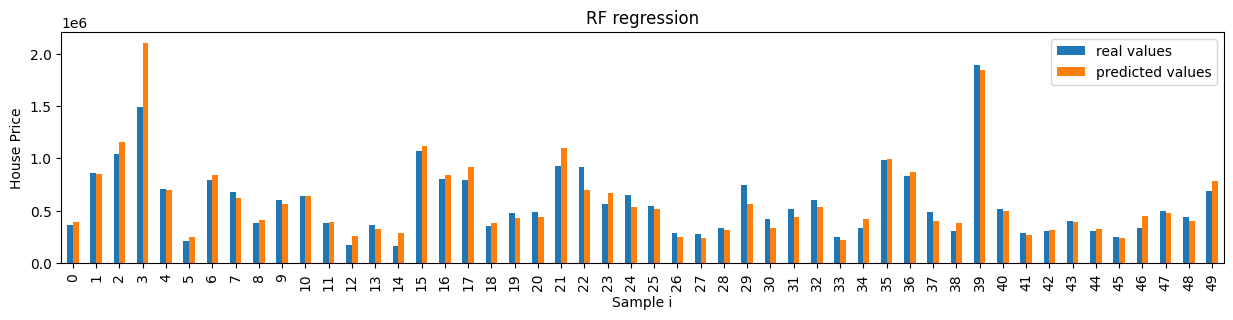

In [18]:
data1 = pd.Series(y_test[:50].ravel())
data2 = pd.Series(y_pred[:50].ravel())

df_new = pd.concat([data1, data2],keys=['real values','predicted values'], axis=1)
#df_new.plot.bar() #bisa pakai cara 1
df_new.plot(kind='bar', figsize=(15,3)) # bisa pakai cara 2

plt.title("RF regression")
plt.xlabel('Sample i')
plt.ylabel('House Price')
plt.show()

# TUGAS

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [20]:
df = pd.read_csv('https://raw.githubusercontent.com/FauzanTrisuladana/content/refs/heads/master/CarPrice_Assignment.csv')

In [21]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [22]:
df.tail()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0
204,205,-1,volvo 264gl,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625.0


In [23]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


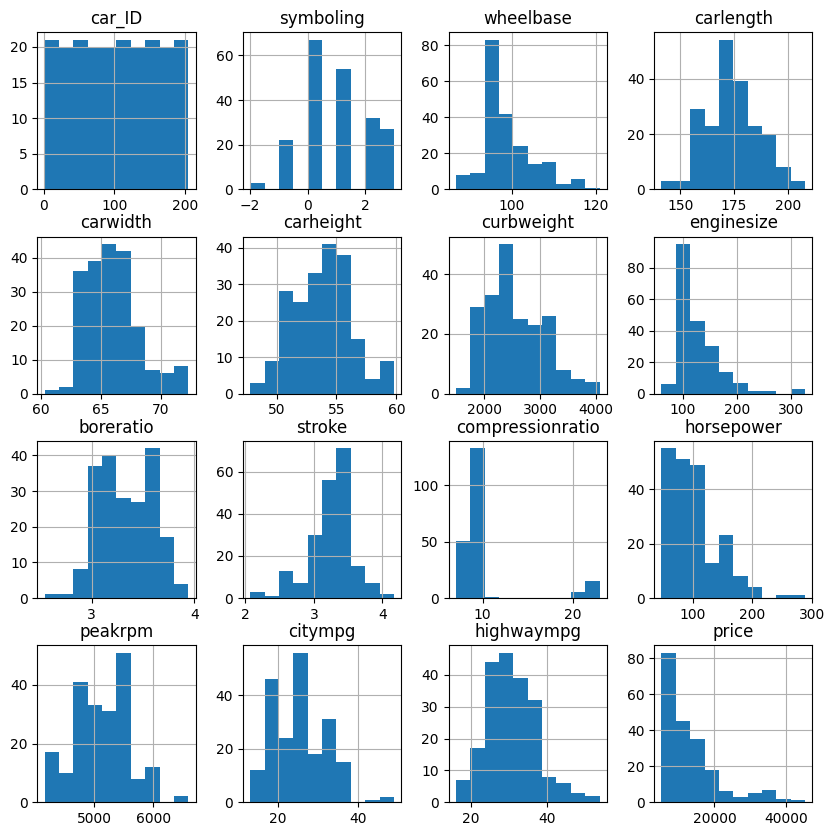

In [24]:
df.hist(figsize=(10,10))
plt.show()

In [25]:
df.corr(numeric_only=True)

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,1.000000,-0.151621,0.129729,0.170636,0.052387,0.255960,0.071962,-0.033930,0.260064,-0.160824,0.150276,-0.015006,-0.203789,0.015940,0.011255,-0.109093
symboling,-0.151621,1.000000,-0.531954,-0.357612,-0.232919,-0.541038,-0.227691,-0.105790,-0.130051,-0.008735,-0.178515,0.070873,0.273606,-0.035823,0.034606,-0.079978
wheelbase,0.129729,-0.531954,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,0.488750,0.160959,0.249786,0.353294,-0.360469,-0.470414,-0.544082,0.577816
carlength,0.170636,-0.357612,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,0.606454,0.129533,0.158414,0.552623,-0.287242,-0.670909,-0.704662,0.682920
carwidth,0.052387,-0.232919,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,0.559150,0.182942,0.181129,0.640732,-0.220012,-0.642704,-0.677218,0.759325
carheight,0.255960,-0.541038,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,0.171071,-0.055307,0.261214,-0.108802,-0.320411,-0.048640,-0.107358,0.119336
curbweight,0.071962,-0.227691,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,0.648480,0.168790,0.151362,0.750739,-0.266243,-0.757414,-0.797465,0.835305
enginesize,-0.033930,-0.105790,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,0.583774,0.203129,0.028971,0.809769,-0.244660,-0.653658,-0.677470,0.874145
boreratio,0.260064,-0.130051,0.488750,0.606454,0.559150,0.171071,0.648480,0.583774,1.000000,-0.055909,0.005197,0.573677,-0.254976,-0.584532,-0.587012,0.553173
stroke,-0.160824,-0.008735,0.160959,0.129533,0.182942,-0.055307,0.168790,0.203129,-0.055909,1.000000,0.186110,0.080940,-0.067964,-0.042145,-0.043931,0.079443


In [26]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [27]:
df_X = df.drop(['car_ID', 'CarName', 'carbody', 'price'], axis=1)
df_y = df['price']

# Perform one-hot encoding for remaining categorical columns
df_X = pd.get_dummies(df_X, columns=['drivewheel', 'enginelocation', 'aspiration', 'fueltype', 'doornumber', 'enginetype', 'cylindernumber', 'fuelsystem'], drop_first=True)

X = df_X.astype(float).values
y = df_y.astype(float).values

Linear Regression

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
reg = LinearRegression()
reg.fit(X_train, y_train)

print('coef of determination training ', reg.score(X_train, y_train))
print('coef of determination testing ', reg.score(X_test, y_test))

print('coefficient')
print(reg.coef_)
print('intercept')
print(reg.intercept_)

print('prediction')
y_pred = reg.predict(X_test)
print(y_pred[:10])
print('real value')
print(y_test[0:10])

coef of determination training  0.9428018897291934
coef of determination testing  0.8946739537167674
coefficient
[ 9.79350457e+01  1.09924813e+01 -7.10721913e+01  5.58571597e+02
  3.37151492e+01  3.33743477e+00  1.31978009e+02 -1.69901995e+03
 -4.32113686e+03  1.67726259e+02  2.59912377e+00  1.85618407e+00
 -1.79577589e+02  1.23434600e+02  3.71201818e+02  1.32480160e+03
  7.41675135e+03  2.24440936e+03  4.15302726e+02 -7.04250331e+02
 -9.08855943e+03 -7.46741417e+02  2.26053350e+03 -1.67882655e+02
 -5.92232857e+03 -1.28979646e+03 -8.36728233e+03 -1.04357768e+04
 -8.63810713e+03  7.63975549e-11 -1.48573779e+04 -1.28979646e+03
  1.40210868e+02  6.38297251e+02 -4.15302726e+02  0.00000000e+00
  6.66764362e+02 -2.04277689e+03 -9.33412007e+02]
intercept
-23387.79716577365
prediction
[28837.72566421 20346.35232838  9917.49442039 13180.75915349
 28440.87341296  5870.50957823  8706.04368778  7681.32013827
 10146.3609631   7693.37925408]
real value
[30760.    17859.167  9549.    11850.    28248.

In [29]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('rmse', rmse)
print('r2', r2)

rmse 2701.379215940705
r2 0.8946739537167674


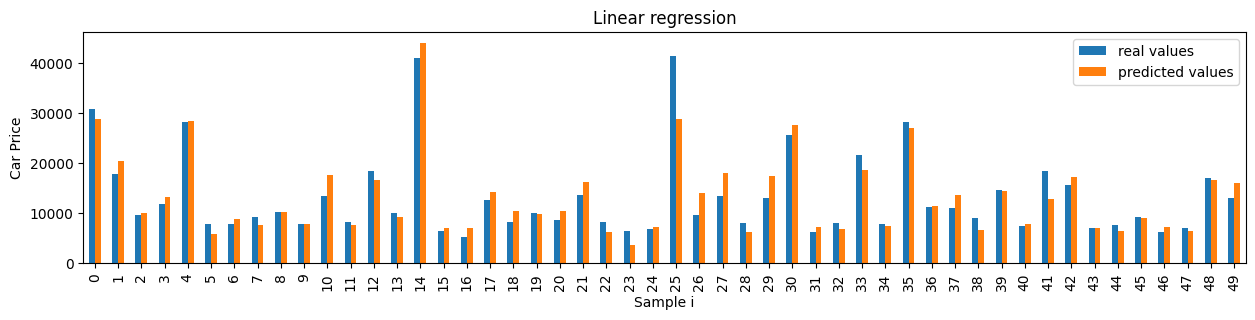

In [30]:
data1 = pd.Series(y_test[:50].ravel())
data2 = pd.Series(y_pred[:50].ravel())

df_new = pd.concat([data1, data2],keys=['real values','predicted values'], axis=1)
#df_new.plot.bar() #bisa pakai cara 1
df_new.plot(kind='bar', figsize=(15,3)) # bisa pakai cara 2

plt.title("Linear regression")
plt.xlabel('Sample i')
plt.ylabel('Car Price')
plt.show()

Decision Tree Regression

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rf = DecisionTreeRegressor()
rf.fit(X_train, y_train)

print('coef of determination training ', rf.score(X_train, y_train))
print('coef of determination testing ', rf.score(X_test, y_test))

print('prediction')
y_pred = rf.predict(X_test)
print(y_pred[:10])
print('real value')
print(y_test[0:10])

coef of determination training  0.9985524829197424
coef of determination testing  0.877804112544733
prediction
[36880. 18950.  8949. 12170. 31600.  7299.  7898.  8358.  9538.  7995.]
real value
[30760.    17859.167  9549.    11850.    28248.     7799.     7788.
  9258.    10198.     7775.   ]


In [32]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('rmse', rmse)
print('r2', r2)

rmse 2909.684885205227
r2 0.877804112544733


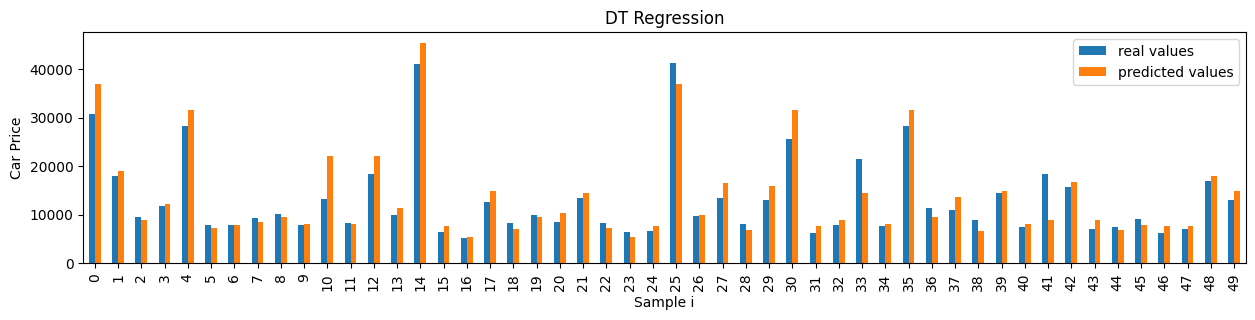

In [33]:
data1 = pd.Series(y_test[:50].ravel())
data2 = pd.Series(y_pred[:50].ravel())

df_new = pd.concat([data1, data2],keys=['real values','predicted values'], axis=1)
#df_new.plot.bar() #bisa pakai cara 1
df_new.plot(kind='bar', figsize=(15,3)) # bisa pakai cara 2

plt.title("DT Regression")
plt.xlabel('Sample i')
plt.ylabel('Car Price')
plt.show()

Random Forest

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

print('coef of determination training ', rf.score(X_train, y_train))
print('coef of determination testing ', rf.score(X_test, y_test))

print('prediction')
y_pred = rf.predict(X_test)
print(y_pred[:10])
print('real value')
print(y_test[0:10])

coef of determination training  0.9849823354735814
coef of determination testing  0.9438557468008568
prediction
[35836.66   19085.95    9203.95   13256.9975 27528.83    6924.8
  8047.085   8012.41   10760.26    8091.2   ]
real value
[30760.    17859.167  9549.    11850.    28248.     7799.     7788.
  9258.    10198.     7775.   ]


In [35]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('rmse', rmse)
print('r2', r2)

rmse 1972.28793422686
r2 0.9438557468008568


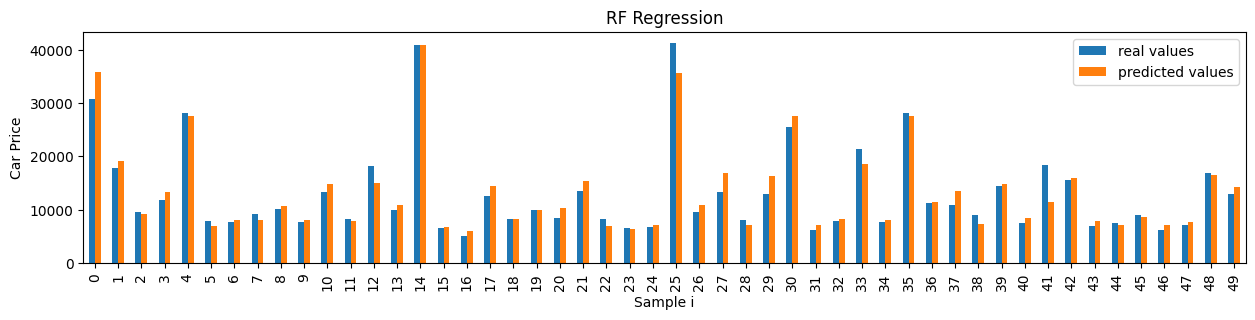

In [36]:
data1 = pd.Series(y_test[:50].ravel())
data2 = pd.Series(y_pred[:50].ravel())

df_new = pd.concat([data1, data2],keys=['real values','predicted values'], axis=1)
#df_new.plot.bar() #bisa pakai cara 1
df_new.plot(kind='bar', figsize=(15,3)) # bisa pakai cara 2

plt.title("RF Regression")
plt.xlabel('Sample i')
plt.ylabel('Car Price')
plt.show()